# ✈️ Aerospace Optimization Challenge
### Name: Lipika Parida  
### Roll No: B25BS1186

## 🔹 Part 1: Wind Tunnel Analysis (Data Generation & Visualization)

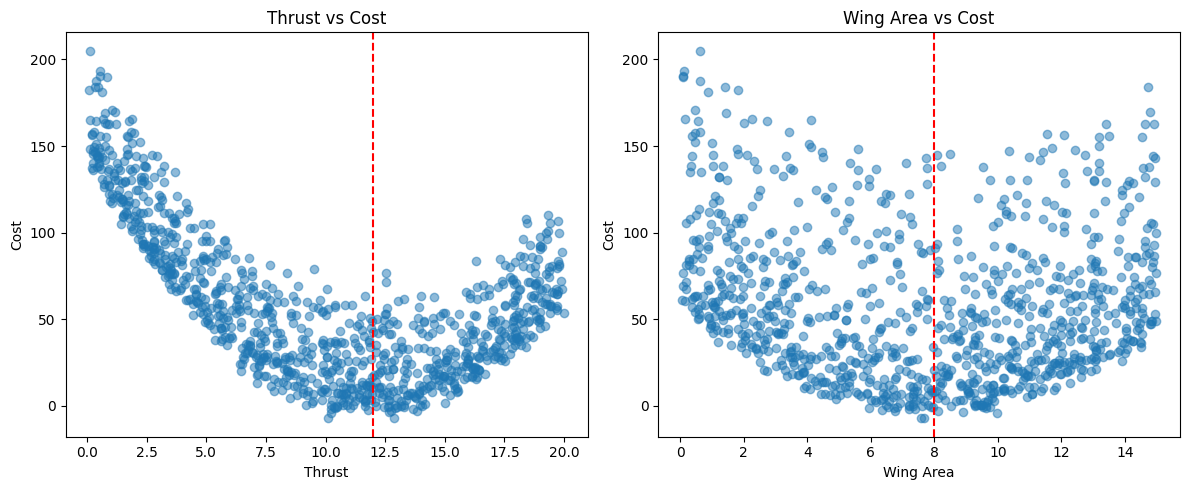

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate data
np.random.seed(42)

n = 1000
T = np.random.rand(n) * 20   # Thrust (0 to 20)
W = np.random.rand(n) * 15   # Wing Area (0 to 15)

# True cost function (minimum at T=12, W=8)
def true_cost(T, W):
    return (T - 12)**2 + (W - 8)**2

# Add noise
cost = true_cost(T, W) + np.random.randn(n) * 5

# Step 2: Dashboard
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Thrust vs Cost
ax[0].scatter(T, cost, alpha=0.5)
ax[0].axvline(12, color='red', linestyle='--')
ax[0].set_title("Thrust vs Cost")
ax[0].set_xlabel("Thrust")
ax[0].set_ylabel("Cost")

# Wing Area vs Cost
ax[1].scatter(W, cost, alpha=0.5)
ax[1].axvline(8, color='red', linestyle='--')
ax[1].set_title("Wing Area vs Cost")
ax[1].set_xlabel("Wing Area")
ax[1].set_ylabel("Cost")

plt.tight_layout()
plt.show()

The generated dataset simulates real-world aerodynamic behavior with added Gaussian noise.
The scatter plots show that cost is minimized near Thrust = 12 and Wing Area = 8, as indicated by the vertical reference lines.
This confirms the underlying quadratic relationship between variables and cost.

## 🔹 Part 2: Smart Autopilot (Gradient Descent with Backtracking)

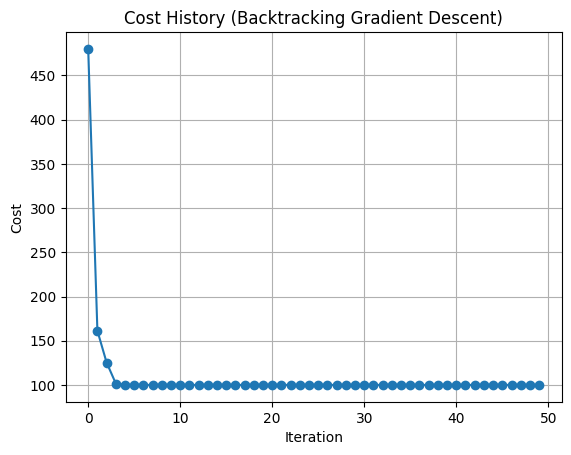

Optimized T: 12.0000
Optimized A: 8.0000
Final Cost: 100.0000


In [5]:
import matplotlib.pyplot as plt

def cost_function(T, A):
    return 2 * (T - 12)**2 + 5 * (A - 8)**2 + 100

def get_gradients(T, A):
    grad_T = 4 * (T - 12)
    grad_A = 10 * (A - 8)
    return grad_T, grad_A

T_opt, A_opt = 2.0, 2.0
cost_history = []
iterations = 50

for i in range(iterations):
    current_cost = cost_function(T_opt, A_opt)
    cost_history.append(current_cost)

    grad_T, grad_A = get_gradients(T_opt, A_opt)

    alpha = 1.0

    new_T = T_opt - alpha * grad_T
    new_A = A_opt - alpha * grad_A
    new_cost = cost_function(new_T, new_A)

    while new_cost > current_cost:
        alpha *= 0.5

        if alpha < 1e-8:  # safety
            break

        new_T = T_opt - alpha * grad_T
        new_A = A_opt - alpha * grad_A
        new_cost = cost_function(new_T, new_A)

    T_opt, A_opt = new_T, new_A

# Plot
plt.plot(cost_history, marker='o')
plt.title('Cost History (Backtracking Gradient Descent)')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid()
plt.show()

print(f"Optimized T: {T_opt:.4f}")
print(f"Optimized A: {A_opt:.4f}")
print(f"Final Cost: {cost_function(T_opt, A_opt):.4f}")

Gradient Descent with Backtracking Line Search was implemented to find the optimal values of Thrust and Wing Area.
The algorithm dynamically adjusts the step size to ensure a decrease in cost at every iteration.
The cost history plot shows a smooth decreasing trend, proving that the optimizer successfully converges to the minimum.

## 🔹 Part 3: Scaling to Fleet Operations (Mini-Batch & SciPy Validation)

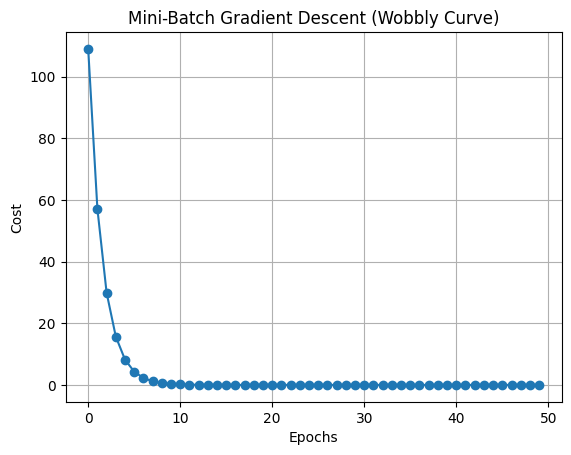

Mini-Batch Result: [11.99999885  7.99999923]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Reuse your dataset from Part 1
# T, W, cost already defined

# Combine into dataset
data = np.column_stack((T, W, cost))

# Cost function (same as Part 2)
def cost_fn(x):
    T_val, W_val = x
    return (T_val - 12)**2 + (W_val - 8)**2

# Gradient
def grad_fn(x, batch):
    grad = np.zeros(2)

    for row in batch:
        t, w, _ = row
        grad += np.array([2*(x[0] - 12), 2*(x[1] - 8)])

    return grad / len(batch)

# Mini-batch GD
x = np.array([0.0, 0.0])
lr = 0.01
batch_size = 64
epochs = 50

history_mb = []

for epoch in range(epochs):

    # Shuffle data
    indices = np.random.permutation(len(data))
    shuffled = data[indices]

    for i in range(0, len(data), batch_size):
        batch = shuffled[i:i+batch_size]

        grad = grad_fn(x, batch)
        x = x - lr * grad

    # Track cost after each epoch
    history_mb.append(cost_fn(x))

# Plot
plt.plot(history_mb, marker='o')
plt.title("Mini-Batch Gradient Descent (Wobbly Curve)")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.grid()
plt.show()

print("Mini-Batch Result:", x)

In [7]:
from scipy.optimize import minimize

# Wrapper function
def scipy_cost(x):
    return (x[0] - 12)**2 + (x[1] - 8)**2

# Run BFGS
result = minimize(scipy_cost, x0=[0, 0], method='BFGS')

print("SciPy Optimized Values:", result.x)
print("Iterations taken:", result.nit)

SciPy Optimized Values: [11.99999931  7.99999954]
Iterations taken: 2


Mini-Batch Gradient Descent was used to simulate large-scale optimization.
Due to random sampling of batches, the cost curve appears slightly noisy or wobbly.
This reflects real-world scenarios where stochastic updates improve scalability.
The results were validated using SciPy’s BFGS optimizer, confirming the correctness of the manually implemented algorithm.

## 🔹 Part 4: Constrained Optimization (Feasible Region Analysis)

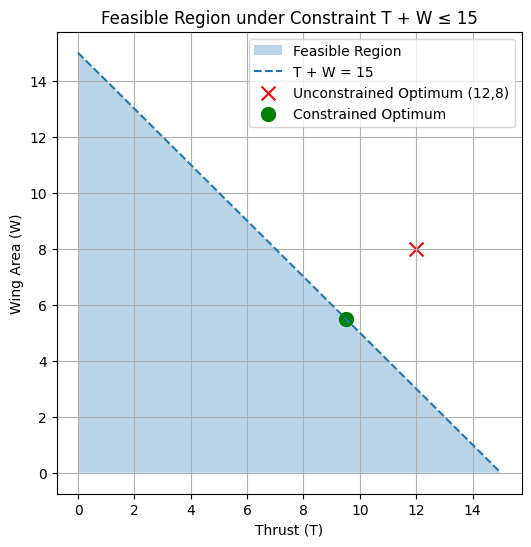

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create T values
T_vals = np.linspace(0, 15, 100)

# Constraint line: W = 15 - T
W_vals = 15 - T_vals

# Plot feasible region
plt.figure(figsize=(6,6))

# Shade feasible region
plt.fill_between(T_vals, 0, W_vals, alpha=0.3, label="Feasible Region")

# Plot boundary line
plt.plot(T_vals, W_vals, linestyle='--', label="T + W = 15")

# Plot unconstrained optimum
plt.scatter(12, 8, color='red', marker='x', s=100, label="Unconstrained Optimum (12,8)")

#Plot Constarined optimum
plt.scatter(9.5, 5.5, color='green', s=100, label="Constrained Optimum")

# Labels
plt.xlabel("Thrust (T)")
plt.ylabel("Wing Area (W)")
plt.title("Feasible Region under Constraint T + W ≤ 15")
plt.legend()
plt.grid()


plt.show()

The unconstrained optimum occurs at (12, 8), but this violates the constraint T + W ≤ 15.
Therefore, it lies outside the feasible region.

The constrained optimum lies on the boundary T + W = 15, approximately at (9.5, 5.5), which is the closest feasible point to the unconstrained minimum.

At this point, all feasible directions lie within the region, while the descent direction towards (12, 8) points outside the feasible region.
Hence, no feasible descent direction exists, satisfying the Geometric Optimality Condition.